<a href="https://colab.research.google.com/github/achalchaudhari70-star/session_18_optional_task/blob/main/trending_shows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/trending_shows_dataset.csv")

In [3]:
print("First 10 Rows:")
df.head(10)

First 10 Rows:


,title,year,imdb_id,tmdb_id,trakt_id,watchers
0,House of the Dragon,2022,tt11198330,94997,154574,9318
1,FROM,2022,tt9813792,124364,188205,7736
2,Rick and Morty,2013,tt2861424,60625,69829,5334
3,The Bear,2022,tt14452776,136315,189717,5175
4,Love Island USA,2019,tt8819906,90521,147958,2798
5,Avatar: The Last Airbender,2024,tt9018736,82452,136561,2710
6,I Will Find You,2026,tt34771210,278178,265319,2687
7,Widow's Bay,2026,tt33332385,270476,254678,2499
8,Dutton Ranch,2026,tt34991493,299167,296208,2456
9,The Agency,2024,tt26656917,219971,202341,2172


In [4]:
print("\nDataset Shape:")
df.shape


Dataset Shape:


(624, 6)

In [5]:
print("\nData Types:")
df.dtypes


Data Types:


,0
title,object
year,int64
imdb_id,object
tmdb_id,int64
trakt_id,int64
watchers,int64


In [11]:
print("Missing Values in Each Column:")
df.isnull().sum()

Missing Values in Each Column:


,0
title,0
year,0
imdb_id,3
tmdb_id,0
trakt_id,0
watchers,0


In [10]:
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())
print("\nRemove duplicate rows:")
df = df.drop_duplicates()
print("\nShape After Removing Duplicates:")
df.shape


Number of Duplicate Rows:
0

Remove duplicate rows:

Shape After Removing Duplicates:


(624, 6)

In [12]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,year,tmdb_id,trakt_id,watchers
count,624.000000,624.000000,624.000000,624.000000
mean,2015.323718,115583.003205,127793.466346,252.729167
std,10.767841,104858.792427,100962.884126,636.642819
min,1959.000000,45.000000,45.000000,50.000000
25%,2010.000000,17610.750000,17532.750000,69.000000
50%,2019.000000,81905.000000,136780.000000,102.000000
75%,2024.000000,220003.750000,202777.250000,206.250000
max,2026.000000,326568.000000,321341.000000,9318.000000


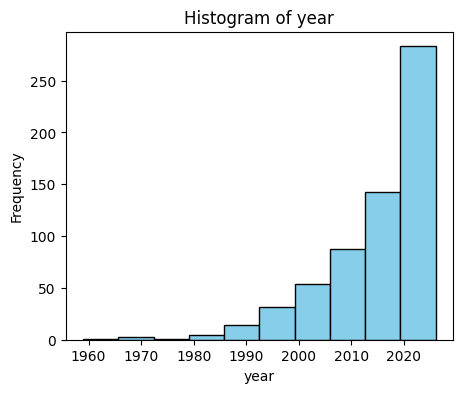

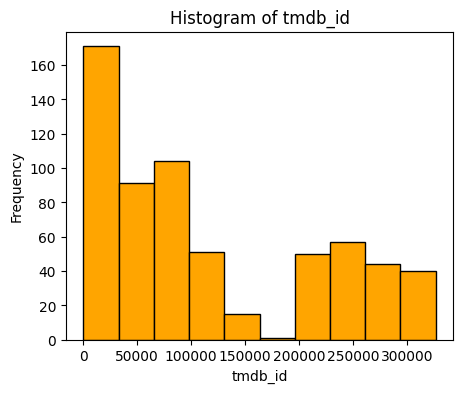

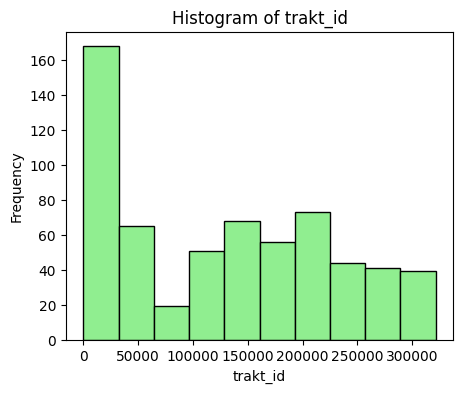

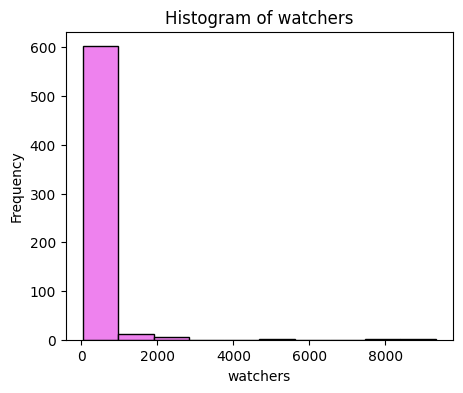

In [13]:
def histogram(column, color):
    plt.figure(figsize=(5,4))
    plt.hist(df[column], bins=10, color=color, edgecolor="black")
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

# Function Calls
histogram("year", "skyblue")
histogram("tmdb_id", "orange")
histogram("trakt_id", "lightgreen")
histogram("watchers", "violet")

In [ ]:
# Observation
# Year: Most shows were released in recent years.
# TMDb ID: Values are randomly distributed because they are unique IDs.
# Trakt ID: Values are randomly distributed because they are unique IDs.
# Watchers: Most shows have fewer watchers, while only a few have very high watcher counts

Text(0, 0.5, 'Watchers')

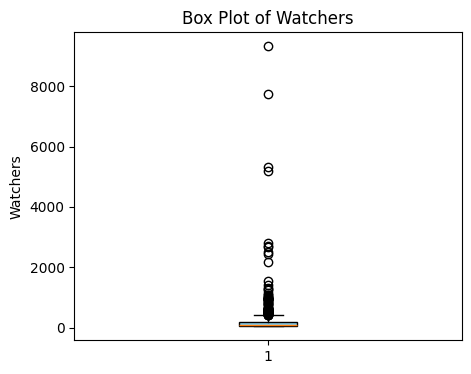

In [14]:
plt.figure(figsize=(5,4))
plt.boxplot(df["watchers"], patch_artist=True,boxprops=dict(facecolor="skyblue"))
plt.title("Box Plot of Watchers")
plt.ylabel("Watchers")

In [ ]:
# Observation
# The Watchers column has several outliers,
# indicating that a few TV shows have significantly higher watcher counts than the majority of shows

Text(0.5, 1.0, 'Correlation Heatmap')

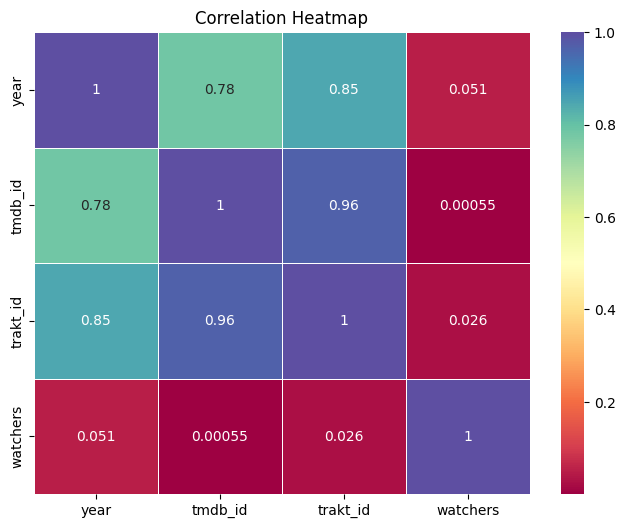

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Spectral",linewidths=0.5)
plt.title("Correlation Heatmap")

In [ ]:
# Observation
# The heatmap shows the correlation between the numeric columns.
# Year has a weak correlation with Watchers.
# TMDb ID and Trakt ID have little or no correlation with Watchers because they are identifier columns.
# Most correlation values are close to 0, indicating weak relationships between the numeric variables.

Text(0.5, 1.0, 'Top 10 Shows by Watchers')

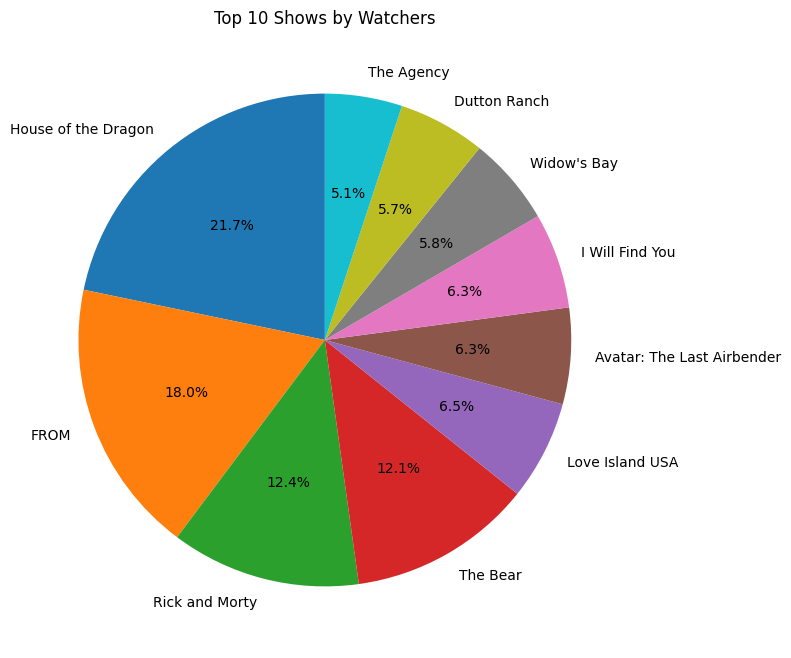

In [30]:
top10 = df.nlargest(10, "watchers")
plt.figure(figsize=(8,8))
plt.pie(top10["watchers"],labels=top10["title"],autopct="%1.1f%%",startangle=90)
plt.title("Top 10 Shows by Watchers")

In [ ]:
# Observation
# The pie chart shows the percentage of watchers for the top 10 TV shows.
# A few shows contribute a larger share of the total watchers.
# The remaining shows have smaller percentages, indicating lower popularity.
# It helps compare the popularity of the top trending shows visually.

In [34]:
# Before Encoding
print("Before Encoding:")
print(df.head())
# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["title"], dtype=int)
# After Encoding
print("\nAfter Encoding:")
print(df_encoded.head())

Before Encoding:
                 title  year     imdb_id  tmdb_id  trakt_id  watchers
0  House of the Dragon  2022  tt11198330    94997    154574      9318
1                 FROM  2022   tt9813792   124364    188205      7736
2       Rick and Morty  2013   tt2861424    60625     69829      5334
3             The Bear  2022  tt14452776   136315    189717      5175
4      Love Island USA  2019   tt8819906    90521    147958      2798

After Encoding:
   year     imdb_id  tmdb_id  trakt_id  watchers  title_100 Cooks  title_1883  \
0  2022  tt11198330    94997    154574      9318                0           0   
1  2022   tt9813792   124364    188205      7736                0           0   
2  2013   tt2861424    60625     69829      5334                0           0   
3  2022  tt14452776   136315    189717      5175                0           0   
4  2019   tt8819906    90521    147958      2798                0           0   

   title_1923  title_2 Broke Girls  title_24  ...  title_Wo

In [ ]:
# Observation
# The title column is converted into multiple binary (0/1) columns.
# Each new column represents one TV show title.
# A value of 1 indicates the corresponding show title is present; 0 indicates it is not.
# The number of columns increases after encoding because each unique title becomes a separate column.

In [37]:
from sklearn.preprocessing import StandardScaler
X = df[["year", "tmdb_id", "trakt_id"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df.head()

,year,tmdb_id,trakt_id
0,0.620518,-0.196479,0.265464
1,0.620518,0.083808,0.598834
2,-0.215975,-0.524535,-0.574577
3,0.620518,0.197872,0.613822
4,0.341687,-0.239199,0.199882


In [ ]:
# Observation
# Standard Scaling transforms the numeric features to have a
# mean of 0 and a standard deviation of 1.
# It brings all numeric features to the same scale.
# This helps machine learning algorithms perform better
# by preventing features with larger values from dominating smaller ones.

Text(0, 0.5, 'watchers')

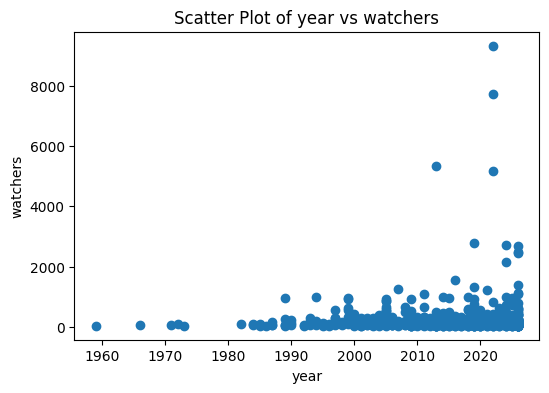

In [39]:
plt.figure(figsize=(6,4))
plt.scatter(df['year'], df['watchers'])
plt.title("Scatter Plot of year vs watchers")
plt.xlabel("year")
plt.ylabel("watchers")

In [ ]:
# Observation:

# No clear relationship between year and watchers is observed.
# Some newer releases have higher numbers of watchers.
# Watchers vary depending on the popularity of the content.

/tmp/ipykernel_952/4005043562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=top10_titles.index, palette="Set2")


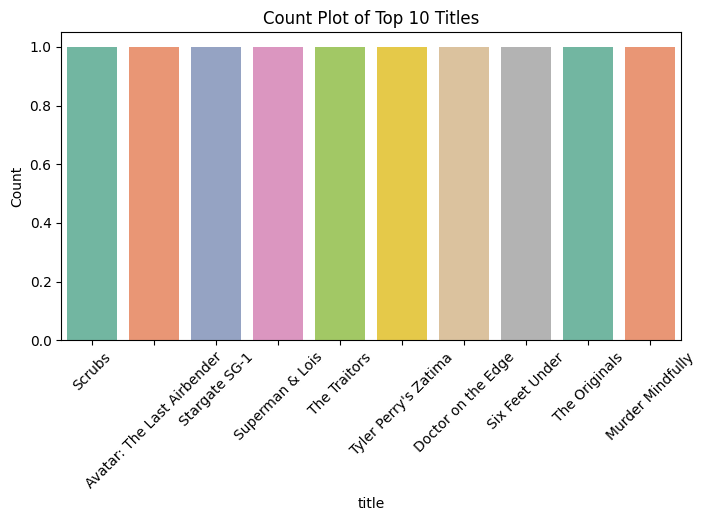

In [42]:
top10_titles = df['title'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.countplot(x=top10_titles.index, palette="Set2")
plt.xlabel("title")
plt.ylabel("Count")
plt.title("Count Plot of Top 10 Titles")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Observation:

# The count plot shows the distribution of the top 10 titles.
# Some titles appear more frequently than others.
# The difference in counts shows the popularity or occurrence of titles in the dataset.